# Exploratory Data Analysis for Cervical Cancer Image Classification

This notebook is the starting point for the deep learning pipeline. It documents the raw image dataset, class balance, image dimensions, processed train/validation/test splits, representative image quality, and preprocessing choices used before model training.

All figures are saved as high-resolution PNG files in `plots/eda` for direct use in thesis documentation.

In [1]:
from pathlib import Path
from collections import defaultdict
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageStat, ImageFilter

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots" / "eda"
TABLES_DIR = PROJECT_ROOT / "results" / "eda"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = ["A", "AGC", "ASC-H", "ASC-US", "HSIL", "LSIL", "NILM", "SC"]
CLASS_DESCRIPTIONS = {
    "A": "Adenocarcinoma",
    "AGC": "Atypical glandular cells",
    "ASC-H": "Atypical squamous cells, cannot exclude HSIL",
    "ASC-US": "Atypical squamous cells of undetermined significance",
    "HSIL": "High-grade squamous intraepithelial lesion",
    "LSIL": "Low-grade squamous intraepithelial lesion",
    "NILM": "Negative for intraepithelial lesion or malignancy",
    "SC": "Squamous carcinoma",
}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
RANDOM_SEED = 42
rng = random.Random(RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw dataset: {RAW_DIR}")
print(f"Processed dataset: {PROCESSED_DIR}")
print(f"EDA plots will be saved to: {PLOTS_DIR}")

Project root: C:\Users\blessy\projects\cancer prediction
Raw dataset: C:\Users\blessy\projects\cancer prediction\data\raw
Processed dataset: C:\Users\blessy\projects\cancer prediction\data\processed
EDA plots will be saved to: C:\Users\blessy\projects\cancer prediction\plots\eda


## Visual Style

The plotting style below is intentionally restrained and publication oriented: white backgrounds, readable typography, consistent class colors, and high DPI exports.

In [2]:
CLASS_PALETTE = {
    "A": "#2F80ED",
    "AGC": "#27AE60",
    "ASC-H": "#F2994A",
    "ASC-US": "#EB5757",
    "HSIL": "#9B51E0",
    "LSIL": "#00A6A6",
    "NILM": "#6FCF97",
    "SC": "#4F4F4F",
}
SPLIT_PALETTE = {"train": "#2F80ED", "val": "#27AE60", "test": "#F2994A"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D0D7DE",
    "axes.labelcolor": "#1F2933",
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "font.size": 10,
    "grid.color": "#E5E7EB",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "savefig.facecolor": "white",
})

def save_figure(fig, filename):
    output_path = PLOTS_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path.relative_to(PROJECT_ROOT)}")


def polish_axes(ax, xlabel=None, ylabel=None, title=None, grid_axis="y"):
    if title:
        ax.set_title(title, pad=14)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

## Raw Dataset Inventory

This section reads the original class folders, records file size and image dimensions, and creates a structured table for later analysis.

In [3]:
if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw dataset folder not found: {RAW_DIR}")

records = []
bad_images = []

for class_name in CLASS_ORDER:
    class_dir = RAW_DIR / class_name
    if not class_dir.exists():
        print(f"Missing class folder: {class_dir}")
        continue

    for image_path in sorted(class_dir.iterdir()):
        if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        try:
            with Image.open(image_path) as image:
                width, height = image.size
            records.append({
                "filepath": image_path,
                "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
                "class_label": class_name,
                "description": CLASS_DESCRIPTIONS[class_name],
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "file_size_kb": image_path.stat().st_size / 1024,
            })
        except Exception as exc:
            bad_images.append({"filepath": image_path, "error": str(exc)})

raw_df = pd.DataFrame(records)
raw_df["class_label"] = pd.Categorical(raw_df["class_label"], categories=CLASS_ORDER, ordered=True)
raw_df = raw_df.sort_values(["class_label", "relative_path"]).reset_index(drop=True)
raw_df.to_csv(TABLES_DIR / "raw_image_inventory.csv", index=False)

summary = pd.DataFrame({
    "Number of images": [len(raw_df)],
    "Number of classes": [raw_df["class_label"].nunique()],
    "Unreadable images": [len(bad_images)],
    "Minimum width": [raw_df["width"].min()],
    "Maximum width": [raw_df["width"].max()],
    "Minimum height": [raw_df["height"].min()],
    "Maximum height": [raw_df["height"].max()],
})
summary.to_csv(TABLES_DIR / "raw_dataset_summary.csv", index=False)
summary

,Number of images,Number of classes,Unreadable images,Minimum width,Maximum width,Minimum height,Maximum height
0,3000,8,0,2592,2592,1944,1944


In [4]:
class_counts = (
    raw_df.groupby(["class_label", "description"], observed=False)
    .size()
    .reset_index(name="count")
)
class_counts["percentage"] = class_counts["count"] / class_counts["count"].sum() * 100
class_counts.to_csv(TABLES_DIR / "raw_class_distribution.csv", index=False)
class_counts

,class_label,description,count,percentage
0,A,Adenocarcinoma,9,0.300000
1,A,Atypical glandular cells,0,0.000000
2,A,Atypical squamous cells of undetermined signif...,0,0.000000
3,A,"Atypical squamous cells, cannot exclude HSIL",0,0.000000
4,A,High-grade squamous intraepithelial lesion,0,0.000000
...,...,...,...,...
59,SC,"Atypical squamous cells, cannot exclude HSIL",0,0.000000
60,SC,High-grade squamous intraepithelial lesion,0,0.000000
61,SC,Low-grade squamous intraepithelial lesion,0,0.000000
62,SC,Negative for intraepithelial lesion or malignancy,0,0.000000


## Class Distribution

Class balance matters in deep learning because dominant classes can bias optimization and inflate accuracy. Weighted and macro metrics should therefore be reported during model evaluation.

Saved: plots\eda\01_raw_class_distribution.png


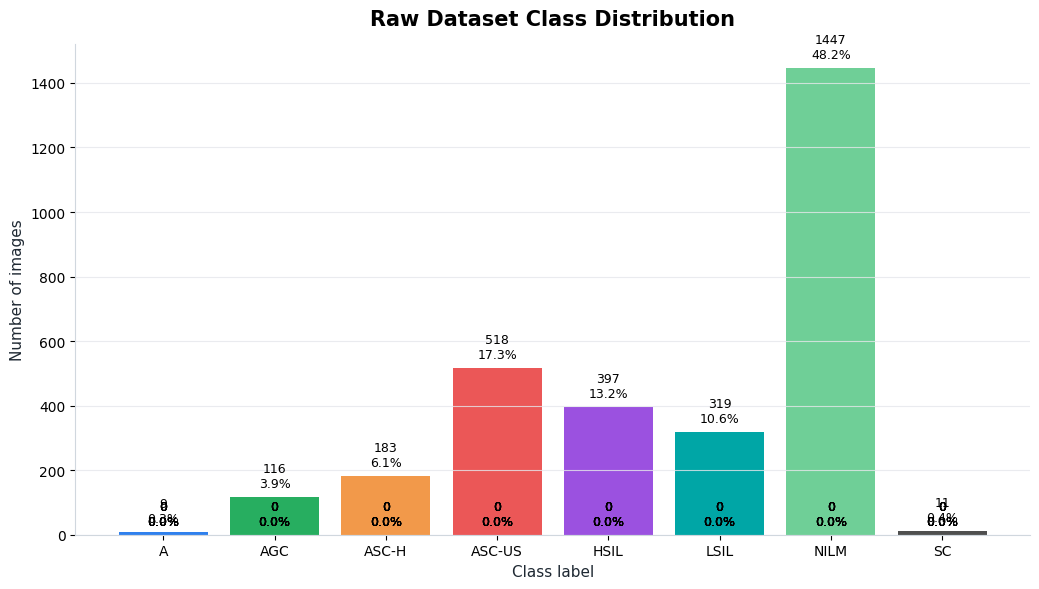

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 6))
colors = [CLASS_PALETTE[class_name] for class_name in class_counts["class_label"].astype(str)]
bars = ax.bar(class_counts["class_label"].astype(str), class_counts["count"], color=colors)

for bar, pct in zip(bars, class_counts["percentage"]):
    height = bar.get_height()
    ax.annotate(
        f"{int(height)}\n{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

polish_axes(ax, "Class label", "Number of images", "Raw Dataset Class Distribution")
fig.tight_layout()
save_figure(fig, "01_raw_class_distribution.png")
plt.show()

## Image Dimensions and File Characteristics

Image dimensions and file sizes are checked before resizing. Consistent input geometry is required for CNN models, while extreme file-size or dimension variation can reveal acquisition differences or preprocessing issues.

Saved: plots\eda\02_original_image_dimensions.png


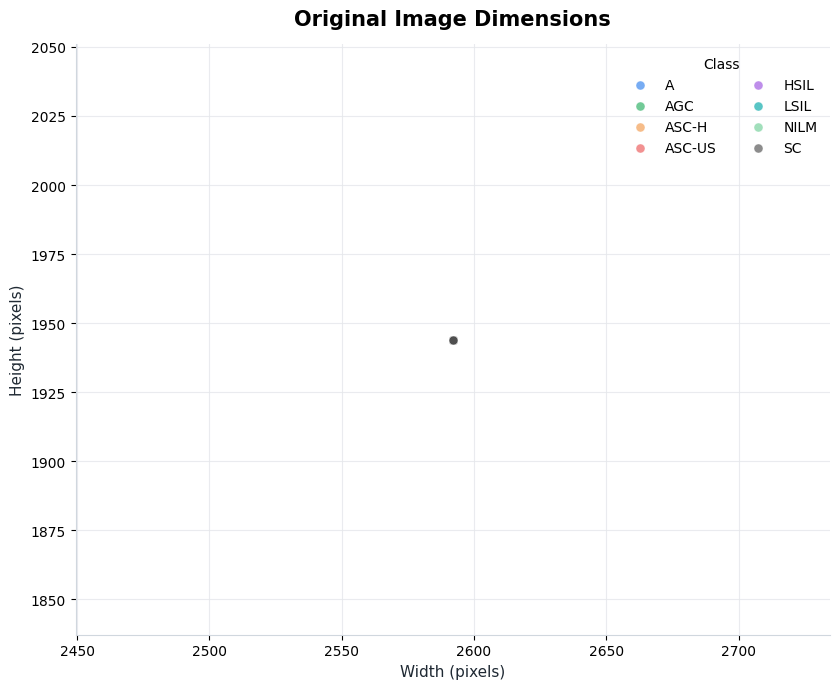

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 7))
for class_name in CLASS_ORDER:
    subset = raw_df[raw_df["class_label"] == class_name]
    ax.scatter(
        subset["width"],
        subset["height"],
        s=42,
        alpha=0.65,
        color=CLASS_PALETTE[class_name],
        edgecolors="white",
        linewidths=0.4,
        label=class_name,
    )

polish_axes(ax, "Width (pixels)", "Height (pixels)", "Original Image Dimensions", grid_axis="both")
ax.legend(title="Class", ncol=2, loc="best")
fig.tight_layout()
save_figure(fig, "02_original_image_dimensions.png")
plt.show()

C:\Users\blessy\AppData\Local\Temp\ipykernel_14904\633858665.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1].boxplot(aspect_data, labels=CLASS_ORDER, patch_artist=True)


Saved: plots\eda\03_file_size_and_aspect_ratio.png


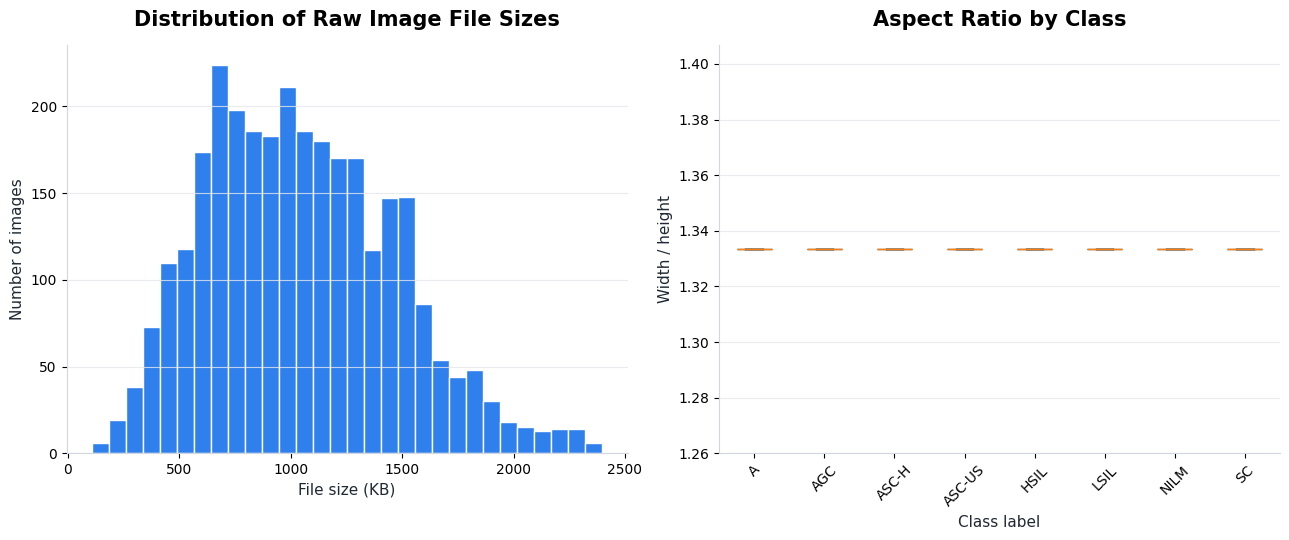

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].hist(raw_df["file_size_kb"], bins=30, color="#2F80ED", edgecolor="white")
polish_axes(axes[0], "File size (KB)", "Number of images", "Distribution of Raw Image File Sizes")

aspect_data = [raw_df.loc[raw_df["class_label"] == class_name, "aspect_ratio"] for class_name in CLASS_ORDER]
box = axes[1].boxplot(aspect_data, labels=CLASS_ORDER, patch_artist=True)
for patch, class_name in zip(box["boxes"], CLASS_ORDER):
    patch.set_facecolor(CLASS_PALETTE[class_name])
    patch.set_alpha(0.78)
polish_axes(axes[1], "Class label", "Width / height", "Aspect Ratio by Class")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
save_figure(fig, "03_file_size_and_aspect_ratio.png")
plt.show()

## Processed Dataset Splits

The processed folders are inspected to confirm the train/validation/test split used for deep learning. These plots document the sample availability seen by the training pipeline.

In [8]:
processed_records = []

for resolution_dir in sorted(PROCESSED_DIR.glob("*x*")):
    if not resolution_dir.is_dir():
        continue
    for split in ["train", "val", "test"]:
        split_dir = resolution_dir / split
        if not split_dir.exists():
            continue
        for class_name in CLASS_ORDER:
            class_dir = split_dir / class_name
            count = len([path for path in class_dir.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS]) if class_dir.exists() else 0
            processed_records.append({
                "resolution": resolution_dir.name,
                "split": split,
                "class_label": class_name,
                "count": count,
            })

processed_df = pd.DataFrame(processed_records)
processed_df.to_csv(TABLES_DIR / "processed_split_counts.csv", index=False)
processed_df.head()

,resolution,split,class_label,count
0,128x128,train,A,8
1,128x128,train,AGC,108
2,128x128,train,ASC-H,171
3,128x128,train,ASC-US,470
4,128x128,train,HSIL,355


Saved: plots\eda\04_processed_split_distribution.png


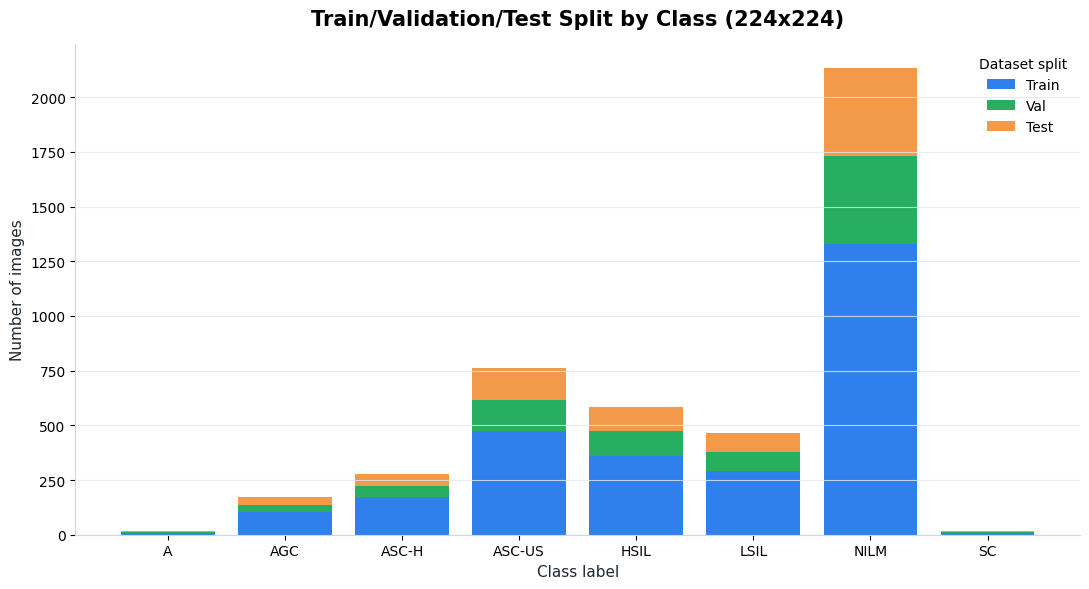

In [9]:
resolution_to_plot = "224x224" if "224x224" in set(processed_df["resolution"]) else processed_df["resolution"].iloc[0]
split_pivot = (
    processed_df[processed_df["resolution"] == resolution_to_plot]
    .pivot_table(index="class_label", columns="split", values="count", fill_value=0, observed=False)
    .reindex(CLASS_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(split_pivot))
for split in ["train", "val", "test"]:
    values = split_pivot[split].values if split in split_pivot.columns else np.zeros(len(split_pivot))
    ax.bar(split_pivot.index.astype(str), values, bottom=bottom, color=SPLIT_PALETTE[split], label=split.title())
    bottom += values

polish_axes(ax, "Class label", "Number of images", f"Train/Validation/Test Split by Class ({resolution_to_plot})")
ax.legend(title="Dataset split")
fig.tight_layout()
save_figure(fig, "04_processed_split_distribution.png")
plt.show()

Saved: plots\eda\05_processed_resolution_totals.png


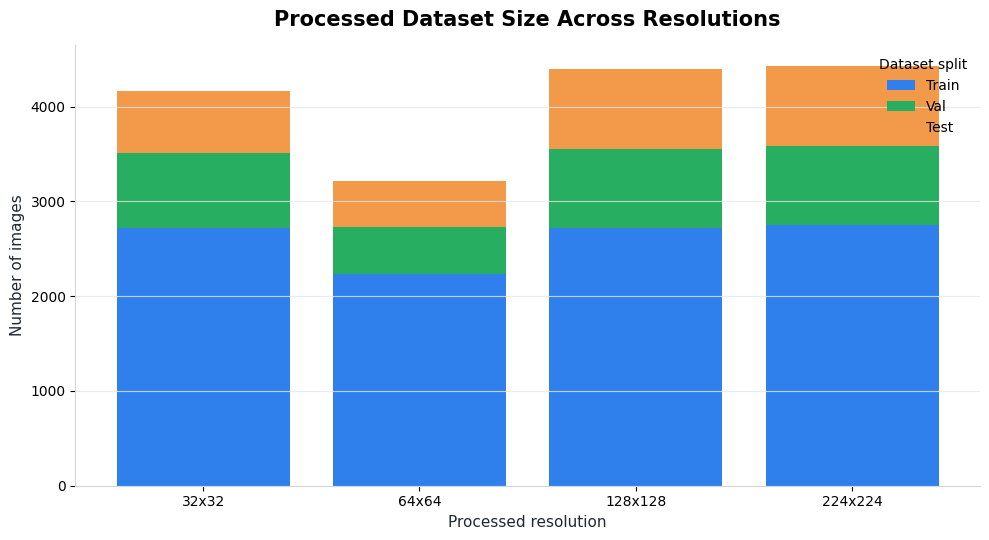

In [10]:
resolution_totals = (
    processed_df.groupby(["resolution", "split"], observed=False)["count"]
    .sum()
    .reset_index()
)
resolution_pivot = resolution_totals.pivot_table(index="resolution", columns="split", values="count", fill_value=0)
resolution_pivot = resolution_pivot.reindex(sorted(resolution_pivot.index, key=lambda value: int(value.split("x")[0])))

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(resolution_pivot))
for split in ["train", "val", "test"]:
    values = resolution_pivot[split].values if split in resolution_pivot.columns else np.zeros(len(resolution_pivot))
    ax.bar(resolution_pivot.index, values, bottom=bottom, color=SPLIT_PALETTE[split], label=split.title())
    bottom += values

polish_axes(ax, "Processed resolution", "Number of images", "Processed Dataset Size Across Resolutions")
ax.legend(title="Dataset split")
fig.tight_layout()
save_figure(fig, "05_processed_resolution_totals.png")
plt.show()

## Representative Image Selection

To avoid displaying poor examples, representative images are selected using a simple quality score based on sharpness and contrast. This produces clearer thesis figures and better communicates the visual characteristics of each class.

In [11]:
def image_quality_score(image_path, thumbnail_size=(256, 256)):
    with Image.open(image_path).convert("RGB") as image:
        image.thumbnail(thumbnail_size)
        gray = ImageOps.grayscale(image)
        sharpness = ImageStat.Stat(gray.filter(ImageFilter.FIND_EDGES)).stddev[0]
        contrast = ImageStat.Stat(gray).stddev[0]
        brightness = ImageStat.Stat(gray).mean[0]
    brightness_penalty = abs(brightness - 128) / 128
    return sharpness * 0.65 + contrast * 0.35 - brightness_penalty * 8

quality_records = []
for class_name in CLASS_ORDER:
    candidates = raw_df.loc[raw_df["class_label"] == class_name, "filepath"].tolist()
    if len(candidates) > 80:
        candidates = rng.sample(candidates, 80)
    for path in candidates:
        try:
            quality_records.append({
                "class_label": class_name,
                "filepath": path,
                "quality_score": image_quality_score(path),
            })
        except Exception as exc:
            print(f"Could not score {path}: {exc}")

quality_df = pd.DataFrame(quality_records)
quality_df.to_csv(TABLES_DIR / "representative_image_quality_scores.csv", index=False)
representative_paths = (
    quality_df.sort_values("quality_score", ascending=False)
    .groupby("class_label", observed=False)
    .head(4)
)
representative_paths.head()

,class_label,filepath,quality_score
124,ASC-H,C:\Users\blessy\projects\cancer prediction\dat...,68.015524
418,NILM,C:\Users\blessy\projects\cancer prediction\dat...,65.705786
98,ASC-H,C:\Users\blessy\projects\cancer prediction\dat...,65.139732
269,HSIL,C:\Users\blessy\projects\cancer prediction\dat...,64.548464
348,LSIL,C:\Users\blessy\projects\cancer prediction\dat...,64.548464


Saved: plots\eda\06_representative_raw_images_by_class.png


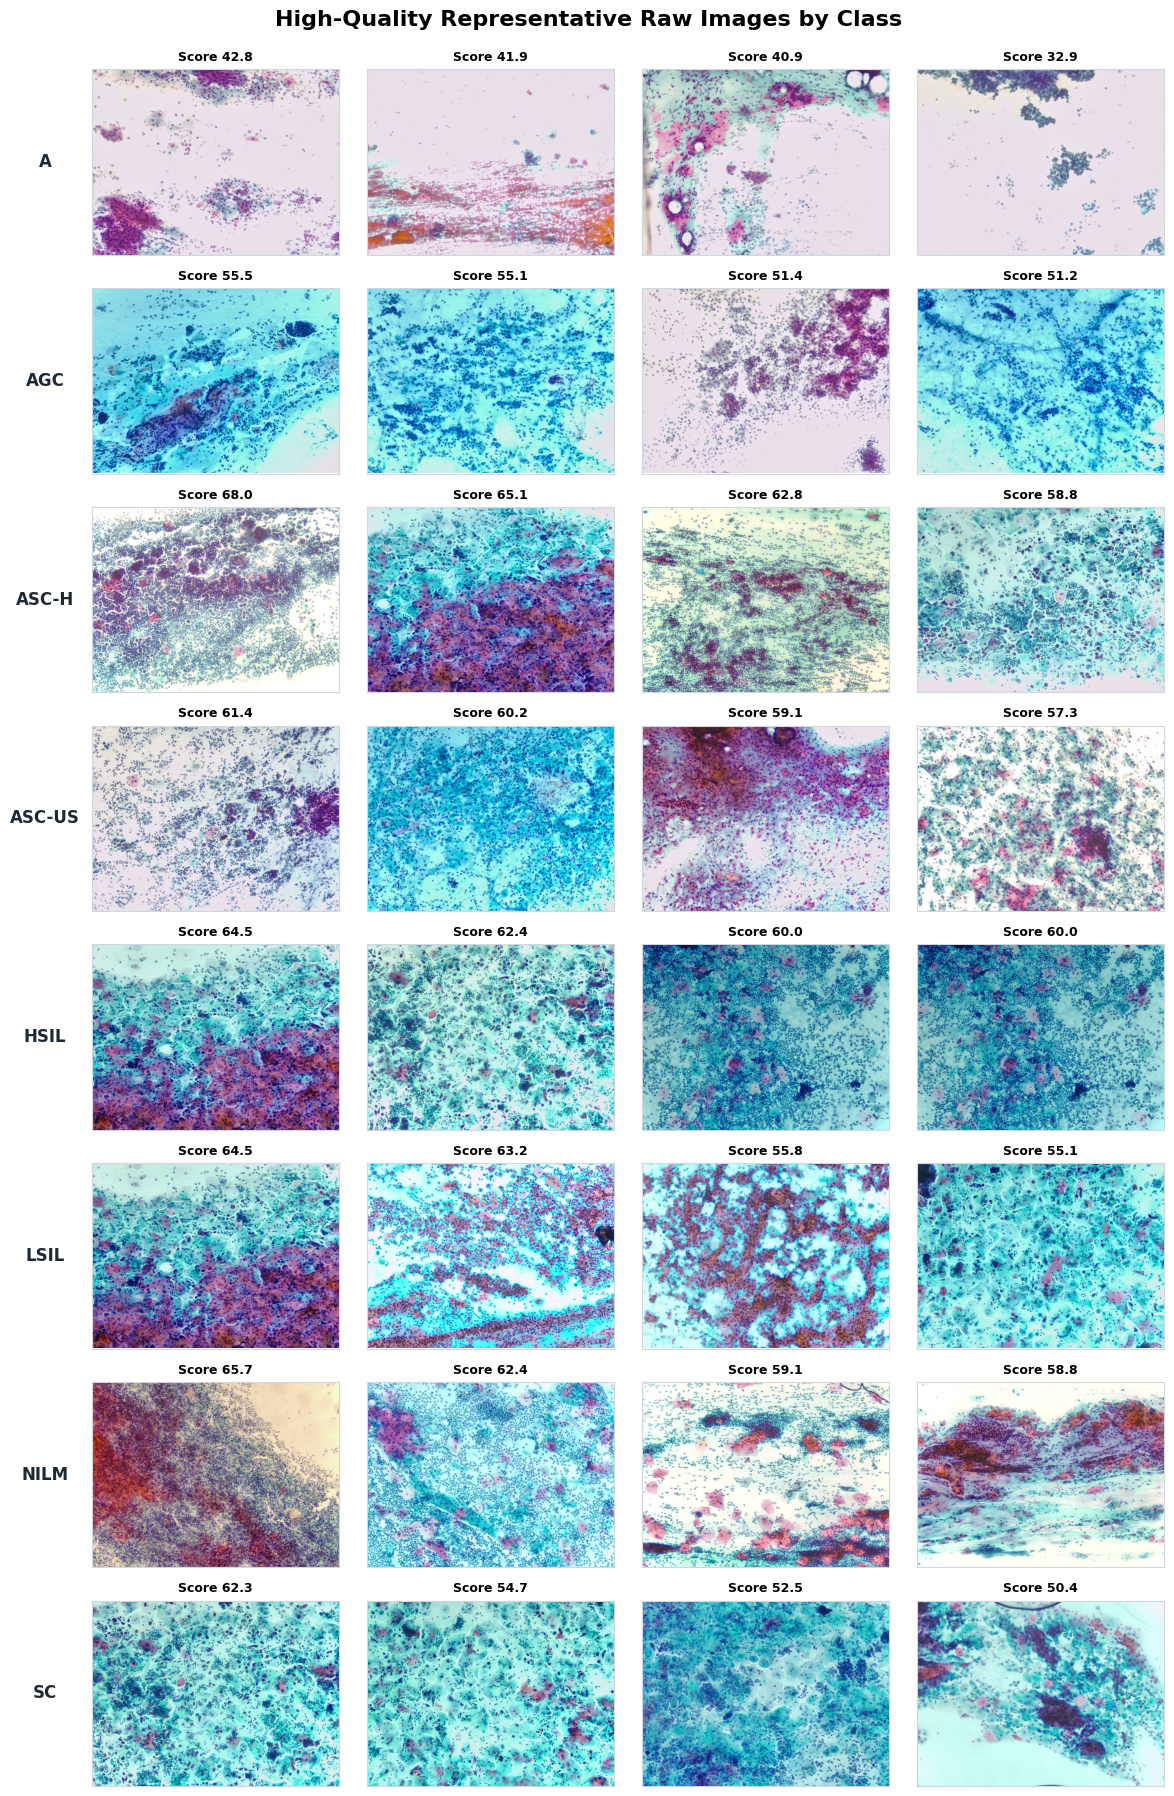

In [12]:
fig, axes = plt.subplots(len(CLASS_ORDER), 4, figsize=(12, 18))

for row, class_name in enumerate(CLASS_ORDER):
    selected = representative_paths[representative_paths["class_label"] == class_name].head(4)
    for col, (_, item) in enumerate(selected.iterrows()):
        ax = axes[row, col]
        with Image.open(item["filepath"]).convert("RGB") as image:
            ax.imshow(image)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(class_name, fontsize=12, fontweight="bold", rotation=0, labelpad=34, va="center")
        ax.set_title(f"Score {item['quality_score']:.1f}", fontsize=9)
        for spine in ax.spines.values():
            spine.set_color("#D0D7DE")

fig.suptitle("High-Quality Representative Raw Images by Class", fontsize=16, fontweight="bold", y=0.995)
fig.tight_layout()
save_figure(fig, "06_representative_raw_images_by_class.png")
plt.show()

## Processed Image Examples

The deep learning models receive resized images. The grid below shows the same diagnostic classes after processing, which confirms that the visual signal remains visible at model input size.

Saved: plots\eda\07_processed_training_samples.png


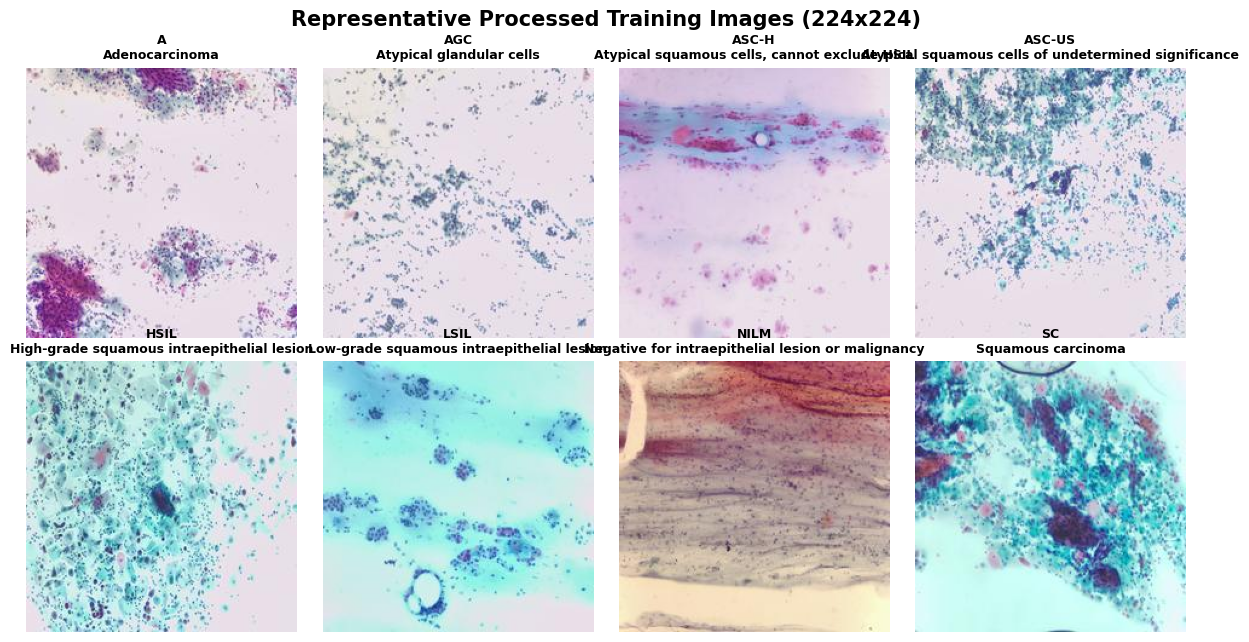

In [13]:
processed_sample_resolution = "224x224" if (PROCESSED_DIR / "224x224").exists() else resolution_to_plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))

for ax, class_name in zip(axes.flat, CLASS_ORDER):
    sample_dir = PROCESSED_DIR / processed_sample_resolution / "train" / class_name
    sample_files = sorted([path for path in sample_dir.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS]) if sample_dir.exists() else []
    if sample_files:
        sample_path = sample_files[len(sample_files) // 2]
        with Image.open(sample_path).convert("RGB") as image:
            ax.imshow(image)
    ax.set_title(f"{class_name}\n{CLASS_DESCRIPTIONS[class_name]}", fontsize=9, fontweight="bold")
    ax.axis("off")

fig.suptitle(f"Representative Processed Training Images ({processed_sample_resolution})", fontsize=15, fontweight="bold")
fig.tight_layout()
save_figure(fig, "07_processed_training_samples.png")
plt.show()

## Resolution Comparison

Multiple input resolutions are used in the experiments. This figure provides visual evidence for how much image detail is retained at each input size.

Saved: plots\eda\08_input_resolution_comparison.png


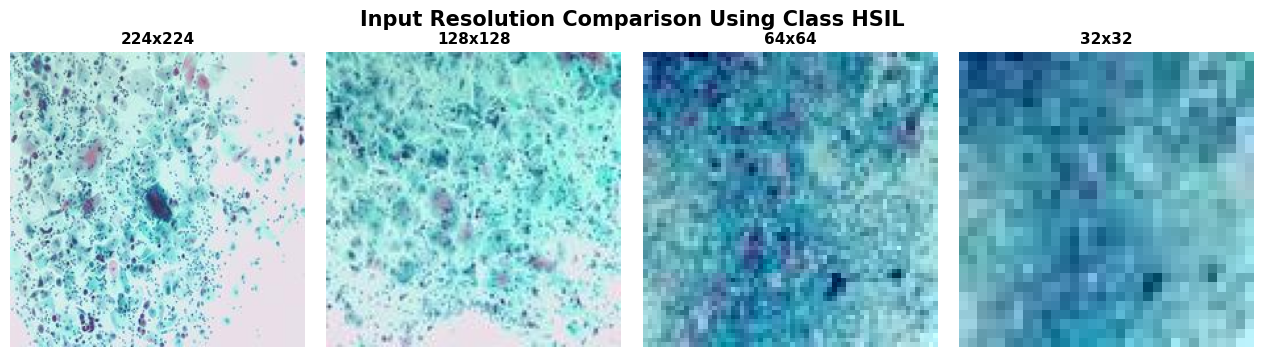

In [14]:
resolution_dirs = sorted([path.name for path in PROCESSED_DIR.glob("*x*") if path.is_dir()], key=lambda value: int(value.split("x")[0]), reverse=True)
comparison_class = "HSIL" if (PROCESSED_DIR / "224x224" / "train" / "HSIL").exists() else CLASS_ORDER[0]

fig, axes = plt.subplots(1, len(resolution_dirs), figsize=(3.2 * len(resolution_dirs), 3.6))
if len(resolution_dirs) == 1:
    axes = [axes]

for ax, resolution_name in zip(axes, resolution_dirs):
    sample_dir = PROCESSED_DIR / resolution_name / "train" / comparison_class
    sample_files = sorted([path for path in sample_dir.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS]) if sample_dir.exists() else []
    if sample_files:
        with Image.open(sample_files[len(sample_files) // 2]).convert("RGB") as image:
            ax.imshow(image)
    ax.set_title(resolution_name, fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle(f"Input Resolution Comparison Using Class {comparison_class}", fontsize=15, fontweight="bold")
fig.tight_layout()
save_figure(fig, "08_input_resolution_comparison.png")
plt.show()

## Preprocessing and Augmentation Preview

The training pipeline uses resizing, rescaling, and augmentation. The preview below illustrates plausible image transformations used to improve generalization while preserving diagnostic structure.

Saved: plots\eda\09_augmentation_preview.png


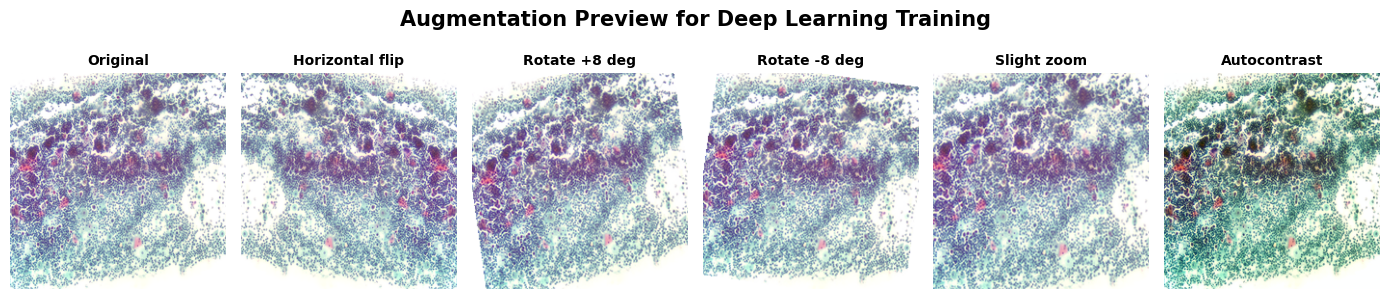

In [15]:
def preview_augmentations(image):
    return [
        ("Original", image),
        ("Horizontal flip", ImageOps.mirror(image)),
        ("Rotate +8 deg", image.rotate(8, resample=Image.Resampling.BICUBIC, fillcolor=(255, 255, 255))),
        ("Rotate -8 deg", image.rotate(-8, resample=Image.Resampling.BICUBIC, fillcolor=(255, 255, 255))),
        ("Slight zoom", image.resize((250, 250), Image.Resampling.LANCZOS).crop((13, 13, 237, 237))),
        ("Autocontrast", ImageOps.autocontrast(image)),
    ]

example_row = representative_paths.sort_values("quality_score", ascending=False).iloc[0]
with Image.open(example_row["filepath"]).convert("RGB") as original:
    preview_image = original.resize((224, 224), Image.Resampling.LANCZOS)

fig, axes = plt.subplots(1, 6, figsize=(14, 3.2))
for ax, (title, image) in zip(axes, preview_augmentations(preview_image)):
    ax.imshow(image)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")

fig.suptitle("Augmentation Preview for Deep Learning Training", fontsize=15, fontweight="bold")
fig.tight_layout()
save_figure(fig, "09_augmentation_preview.png")
plt.show()

## EDA Findings for Thesis Documentation

Use the generated tables and figures to support the methodology chapter:

- The dataset contains eight cervical cytology classes with visible class imbalance; therefore weighted and macro evaluation metrics are necessary.
- Images are resized into multiple resolutions for model comparison, allowing the thesis to discuss the trade-off between visual detail and computational cost.
- Representative examples confirm that class-specific morphology remains visually inspectable after preprocessing.
- Augmentation should be applied only to the training split to improve generalization while keeping validation and test evaluation unbiased.

The PNG figures saved in `plots/eda` are ready to insert into the thesis.